In [164]:
# import modules

import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

In [2]:
# constants

rho = 1.225 # air density at sea level
g = 9.81

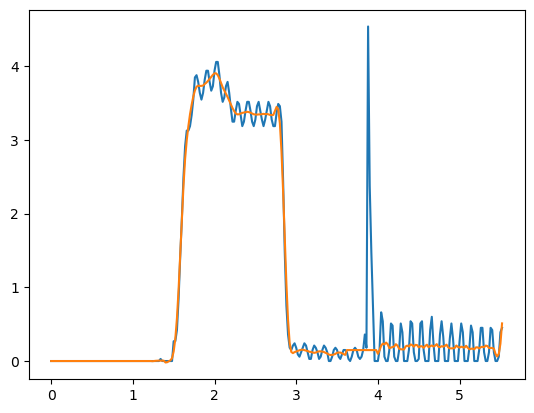

In [375]:
"""
# load a8

a8_3_data = np.loadtxt("A8-3_ThrustData.txt", skiprows=6)
a8_3_t_data = a8_3_data[:,0]
a8_3_t_force = a8_3_data[:,1]

# plt.plot(a8_3_t_data, a8_3_t_force) # plot to view data

# clean data
zero_offset = a8_3_t_force[0]
a8_3_t_force -= zero_offset # zero values
a8_3_t_force *= -1 # flip sign
a8_3_t_force = np.clip(a8_3_t_force, 0, None) # removes negatives 
"""

def load_data(path:str, smooth_level:int=0):
    # load data
    data = np.loadtxt(path, skiprows=6)
    t_data = data[:,0]
    f_data = data[:,1]

    # clean data
    zero_offset = f_data[0]
    f_data -= zero_offset # zero values
    f_data *= -1 # flip sign
    f_data = np.clip(f_data, 0, None) # removes negatives 

    if smooth_level != 0:
        f_data = savgol_filter(f_data, window_length=smooth_level, polyorder=3)

    #plt.plot(t_data, f_data) # plot to view data

    return t_data, f_data

a8_3_t_data, a8_3_f_data = load_data("A8-3_ThrustData.txt")
#plt.plot(a8_3_t_data, a8_3_f_data)
b4_2_t_data, b4_2_f_data = load_data("B4-2_ThrustData.txt")
#plt.plot(b4_2_t_data, b4_2_f_data)
b6_2_t_data, b6_2_f_data = load_data("B6-2_ThrustData.txt")
plt.plot(b6_2_t_data, b6_2_f_data)


b6_2_t_data, b6_2_f_data = load_data("B6-2_ThrustData.txt", 11)

# smooth out the second spike manually
b6_2_f_data[(b6_2_t_data > 3.6) & (b6_2_t_data < 4)] = b6_2_f_data[3.1 == b6_2_t_data]
plt.plot(b6_2_t_data, b6_2_f_data)


In [377]:
# engine model

def thrust(t, A, t_peak, sr, sf, t_end=-1, n_plat=-1):
    spike = np.where(
        t < t_peak,
        A * np.exp(-((t - t_peak)**2) / (2 * sr**2)),
        A * np.exp(-((t - t_peak)**2) / (2 * sf**2)))
    
    if n_plat != -1 and t_end != -1:
        plateau = np.where((t > t_peak) & (t < t_end), n_plat, 0)

        return spike+plateau
    
    return spike


# get params for model
# sr will be inputted and compared for accuracy
def estimate_params(t_data, f_data, sr, t_end, n_plat):
    A = f_data.max()
    t_peak = t_data[np.argmax(f_data)]
    sf = (t_data[f_data > 0.1].max() - t_peak) / 2

    return [A, t_peak, sr, sf, t_end, n_plat]


In [395]:
def engine_model(t_data, f_Data, sr, t_end=-1, n_plat=-1):

    weights = np.ones_like(f_Data)
    weights[f_Data > 4.2] = 10

    p0 = estimate_params(t_data, f_Data, sr, t_end, n_plat)
    popt, _ = curve_fit(thrust, t_data, f_Data, p0=p0, sigma=1/weights)
    return lambda t: thrust(t, *popt)




a8_3_engine = engine_model(a8_3_t_data, a8_3_f_data, 0.05)
b4_2_engine = engine_model(b4_2_t_data, b4_2_f_data, 0.05, 4, 3)
b6_2_engine = engine_model(b6_2_t_data, b6_2_f_data, .12, 3.9, 4)

/tmp/ipykernel_26415/431531182.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(thrust, t_data, f_Data, p0=p0, sigma=1/weights)
